In [62]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from tqdm import tqdm

from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.models import Sequential

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,concatenate
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
import opendatasets as od 

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization, Concatenate


from PIL import Image
import pathlib


In [63]:
# getting the images 
imageDir = "/ocular-disease-recognition-odir5k/ODIR-5k/ODIR-5k/" 

trainPathJoin = 'ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images/'
trainImageDir = pathlib.Path(trainPathJoin).with_suffix('')
testPathJoin = 'ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Testing Images/'
testImageDir = pathlib.Path(testPathJoin).with_suffix('')

In [64]:
data = pd.read_excel('./Processed_data.xlsx')

In [65]:
data

,Patient ID,Patient Age,Patient Sex,Filename,Diagnosis,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,cataract,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,"laser spot,moderate non proliferative retinopathy",0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,normal fundus,1,0,0,0,0,0,0,0
4,4,53,Male,4_left.jpg,macular epiretinal membrane,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,4686,63,Male,4686_right.jpg,proliferative diabetic retinopathy,0,1,0,0,0,0,0,0
6996,4688,42,Male,4688_right.jpg,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0
6997,4689,54,Male,4689_right.jpg,normal fundus,1,0,0,0,0,0,0,0
6998,4690,57,Male,4690_right.jpg,mild nonproliferative retinopathy,0,1,0,0,0,0,0,0


In [42]:
print(2+2)

4


In [66]:
newData = data.drop(['Patient ID', 'Patient Sex'], axis=1)
newData.head()

,Patient Age,Filename,Diagnosis,N,D,G,C,A,H,M,O
0,69,0_left.jpg,cataract,0,0,0,1,0,0,0,0
1,57,1_left.jpg,normal fundus,1,0,0,0,0,0,0,0
2,42,2_left.jpg,"laser spot,moderate non proliferative retinopathy",0,1,0,0,0,0,0,1
3,66,3_left.jpg,normal fundus,1,0,0,0,0,0,0,0
4,53,4_left.jpg,macular epiretinal membrane,0,0,0,0,0,0,0,1


In [67]:
#perform Min-Max Scaling of the Age column
age_scaler = MinMaxScaler()
newData['Patient Age'] = age_scaler.fit_transform(newData[['Patient Age']])

In [68]:
newData.head()

,Patient Age,Filename,Diagnosis,N,D,G,C,A,H,M,O
0,0.755556,0_left.jpg,cataract,0,0,0,1,0,0,0,0
1,0.622222,1_left.jpg,normal fundus,1,0,0,0,0,0,0,0
2,0.455556,2_left.jpg,"laser spot,moderate non proliferative retinopathy",0,1,0,0,0,0,0,1
3,0.722222,3_left.jpg,normal fundus,1,0,0,0,0,0,0,0
4,0.577778,4_left.jpg,macular epiretinal membrane,0,0,0,0,0,0,0,1


In [69]:
img_width = 300
img_height = 300

X = []

for i in tqdm(range(newData.shape[0])):
    path = trainPathJoin + newData['Filename'][i]
    img = image
    img = image.load_img(path, target_size=(img_width, img_height, 3))
    img = image.img_to_array(img)
    img = img/255.0
    X.append(img)

X = np.array(X)
X.shape

100%|███████████████████████████████████████| 7000/7000 [04:45<00:00, 24.56it/s]


(7000, 300, 300, 3)

In [19]:

current_working_directory = os.getcwd()

directory_path = '/ocular-disease-recognition-odir5k/ODIR-5k/ODIR-5k/Training_Images'
try:
    files_in_directory = os.listdir(directory_path)
except FileNotFoundError:
    files_in_directory = "Directory not found"

current_working_directory, files_in_directory


('/Users/gangas/Untitled/notebooks', 'Directory not found')

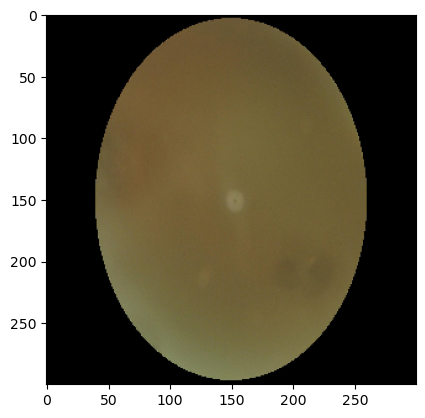

In [70]:
plt.imshow(X[0])

In [71]:
Y = data.drop(['Diagnosis','Patient ID','Patient Age', 'Patient Sex', 'Filename'], axis = 1)
Y = Y.to_numpy()
print(Y.shape)
Y

(7000, 8)


array([[0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 1],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0]])

In [72]:
# Splitting the image data and labels into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, random_state = 0, test_size = 0.15)

# newdata contains the scaled 'Patient Age' after performing min-max scaling
scaled_age = newData['Patient Age']
scaled_age_train, scaled_age_test = train_test_split(scaled_age, test_size=0.15, random_state=0)


In [73]:
X_train[0].shape

(300, 300, 3)

### Define Image Input and CNN Layers

In [74]:
image_input = Input(shape=X_train[0].shape)

# CNN layers
x = Conv2D(16, (3,3), activation='relu')(image_input)
x = BatchNormalization()(x)
x = MaxPool2D(2,2)(x)
x = Dropout(0.3)(x)

# Adding more CNN layers as in your existing model
x = Conv2D(32, (3,3), activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPool2D(2,2)(x)
x = Dropout(0.3)(x)

x = Conv2D(64, (3,3), activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPool2D(2,2)(x)
x = Dropout(0.4)(x)

x = Conv2D(128, (3,3), activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPool2D(2,2)(x)
x = Dropout(0.5)(x)

x = Flatten()(x)

In [75]:
# Define the input for the age data
age_input = Input(shape=(1,))


In [76]:
# Concatenate the outputs of the image CNN and the age input
combined = Concatenate()([x, age_input])


In [77]:
# Dense layers after combining image and age data
# Dense layers
y = Dense(128, activation='relu')(combined)
y = BatchNormalization()(y)
y = Dropout(0.5)(y)

y = Dense(128, activation='relu')(y)
y = BatchNormalization()(y)
y = Dropout(0.5)(y)

output = Dense(8, activation='sigmoid')(y)


In [78]:
# Create Model
model = Model(inputs=[image_input, age_input], outputs=output)


In [59]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 300, 300, 3)]        0         []                            
                                                                                                  
 conv2d_5 (Conv2D)           (None, 298, 298, 16)         448       ['input_5[0][0]']             
                                                                                                  
 batch_normalization_5 (Bat  (None, 298, 298, 16)         64        ['conv2d_5[0][0]']            
 chNormalization)                                                                                 
                                                                                                  
 max_pooling2d_5 (MaxPoolin  (None, 149, 149, 16)         0         ['batch_normalization_5[0]

In [79]:
# Compile the Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit([X_train, scaled_age_train], y_train, epochs=10, validation_data=([X_test, scaled_age_test], y_test))

Epoch 1/10
186/186 [==============================] - 280s 1s/step - loss: 0.7140 - accuracy: 0.2086 - val_loss: 0.4326 - val_accuracy: 0.4619
Epoch 2/10
186/186 [==============================] - 267s 1s/step - loss: 0.4064 - accuracy: 0.3780 - val_loss: 0.3839 - val_accuracy: 0.4619
Epoch 3/10
186/186 [==============================] - 258s 1s/step - loss: 0.3478 - accuracy: 0.4266 - val_loss: 0.3173 - val_accuracy: 0.4619
Epoch 4/10
186/186 [==============================] - 252s 1s/step - loss: 0.3343 - accuracy: 0.4402 - val_loss: 0.3237 - val_accuracy: 0.4619
Epoch 5/10
186/186 [==============================] - 261s 1s/step - loss: 0.3296 - accuracy: 0.4546 - val_loss: 0.3183 - val_accuracy: 0.4629
Epoch 6/10
186/186 [==============================] - 265s 1s/step - loss: 0.3269 - accuracy: 0.4508 - val_loss: 0.3112 - val_accuracy: 0.4629
Epoch 7/10
186/186 [==============================] - 270s 1s/step - loss: 0.3194 - accuracy: 0.4565 - val_loss: 0.3095 - val_accuracy: 0.4629

In [81]:
history = model.fit([X_train, scaled_age_train], y_train, epochs=10, validation_data=([X_test, scaled_age_test], y_test))

Epoch 1/10
186/186 [==============================] - 270s 1s/step - loss: 0.3081 - accuracy: 0.4750 - val_loss: 0.3131 - val_accuracy: 0.4629
Epoch 2/10
186/186 [==============================] - 263s 1s/step - loss: 0.3088 - accuracy: 0.4766 - val_loss: 0.3150 - val_accuracy: 0.4638
Epoch 3/10
186/186 [==============================] - 262s 1s/step - loss: 0.3087 - accuracy: 0.4713 - val_loss: 0.3064 - val_accuracy: 0.4705
Epoch 4/10
186/186 [==============================] - 266s 1s/step - loss: 0.3091 - accuracy: 0.4771 - val_loss: 0.3054 - val_accuracy: 0.4686
Epoch 5/10
186/186 [==============================] - 265s 1s/step - loss: 0.3057 - accuracy: 0.4753 - val_loss: 0.2996 - val_accuracy: 0.4714
Epoch 6/10
186/186 [==============================] - 266s 1s/step - loss: 0.3043 - accuracy: 0.4729 - val_loss: 0.3015 - val_accuracy: 0.4733
Epoch 7/10
186/186 [==============================] - 265s 1s/step - loss: 0.3027 - accuracy: 0.4771 - val_loss: 0.3005 - val_accuracy: 0.4733

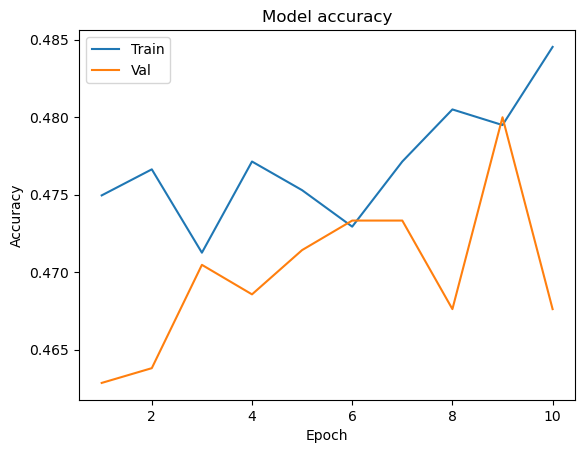

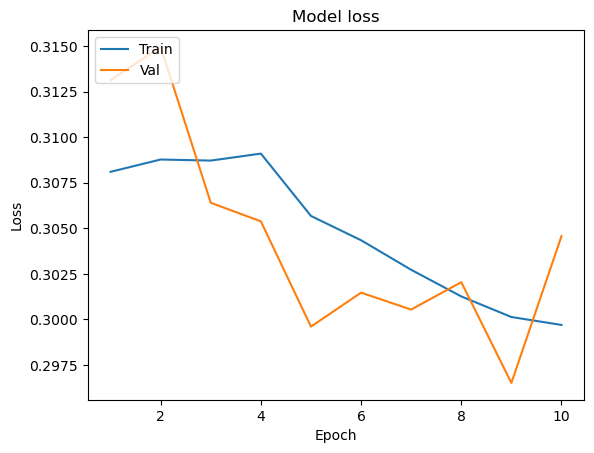

In [83]:
def plot_learningCurve(history, epoch):
  # Plot training & validation accuracy values
  epoch_range = range(1, epoch+1)
  plt.plot(epoch_range, history.history['accuracy'])
  plt.plot(epoch_range, history.history['val_accuracy'])
  plt.title('Model accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Val'], loc='upper left')
  plt.show()

  # Plot training & validation loss values
  plt.plot(epoch_range, history.history['loss'])
  plt.plot(epoch_range, history.history['val_loss'])
  plt.title('Model loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Val'], loc='upper left')
  plt.show()

plot_learningCurve(history, 10)